In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. Load Data
match   = pd.read_csv("../data/gold_match_with_league_standings.csv")
tickets = pd.read_csv("../data/gold_match_tickets.csv")
context = pd.read_csv("../data/gold_match_context.csv")

# 2. Filter and Merge
match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

# Handle potential suffix issues from merges
if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

# Clean up baseline data
df = df[df["away_team"] != "OH Leuven"]

nan_values_last_result = df[df[["last_result_vs_opponent"]].isna().any(axis=1)]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])
# df = df.dropna(subset=["tickets_scanned"])

In [17]:
# 3. Parse target/results
def parse_result(value):
    if pd.isna(value): return 0
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
nan_values_last_result_numeric = df[df[["last_result_numeric"]].isna().any(axis=1)]
df = df.dropna(subset=["last_result_numeric"])


In [18]:
# -------------------------------------------------------------------
# CRITICAL FIX 1: SORT CHRONOLOGICALLY AND RESET INDEX
# All time-series features must be calculated chronologically to prevent data leakage.
# -------------------------------------------------------------------
df["match_date"] = pd.to_datetime(df["match_date"])
df = df.sort_values("match_date").reset_index(drop=True)

In [19]:
# -------------------------------------------------------------------
# CRITICAL FIX 2: GLOBAL TIME-SERIES FEATURES
# Calculate lags globally before splitting to avoid constant values in test sets.
# -------------------------------------------------------------------
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"]        = df["tickets_scanned"].shift(1).rolling(3).mean()

In [20]:
# Calculate expanding opponent average (average attendance for this opponent strictly UP TO this date)
df["opponent_avg"] = df.groupby("away_team")["tickets_scanned"].transform(lambda x: x.shift().expanding().mean())
df["season_expanding_avg"] = df["tickets_scanned"].shift().expanding().mean()
df["opponent_avg"] = df["opponent_avg"].fillna(df["season_expanding_avg"]) # Fallback for first-time opponents

In [21]:
df["match_date"] = pd.to_datetime(df["match_date"])
df["month"] = df['match_date'].dt.month
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [22]:
# Calculate Same Fixture Last Time (strictly UP TO this date)
def get_last_fixture(row, dataframe):
    past = dataframe[(dataframe["away_team"] == row["away_team"]) & (dataframe["match_date"] < row["match_date"])]
    if not past.empty:
        return past.iloc[-1]["tickets_scanned"]
    return np.nan

df["same_fixture_baseline"] = df.apply(lambda r: get_last_fixture(r, df), axis=1)
df["same_fixture_baseline"] = df["same_fixture_baseline"].fillna(df["season_expanding_avg"])

In [23]:
# Fix recent form logic to compare actual Dates, not original CSV row indices
records = []
for idx, row in df.iterrows():
    past = df[(df["away_team"] == row["away_team"]) & (df["match_date"] < row["match_date"])]
    results = past["last_result_numeric"].tail(3).tolist()

    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

In [24]:
df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = df["result_minus_1"].fillna(0) + df["result_minus_2"].fillna(0) + df["result_minus_3"].fillna(0)

df["school_holiday_name"] = df["school_holiday_name"].fillna("None")

df["kickoff_time_local"] = pd.to_datetime(df["kickoff_time_local"], format='%H:%M:%S')
df["kickoff_time_local"] = pd.to_datetime(df["kickoff_time_local"], format='%H:%M:%S').dt.hour
df["is_18_hours"] = df["kickoff_time_local"] == 18

In [25]:
df[df[["last_home_attendance", "rolling_avg_3"]].isna().any(axis=1)]

,match_id,match_date,kickoff_time_local,match_date_utc,kickoff_time_utc,matchday,competition_id,competition_name,season,season_id,...,opponent_avg,season_expanding_avg,month,month_cos,same_fixture_baseline,result_minus_1,result_minus_2,result_minus_3,points_last_3,is_18_hours
0,d4mn5ksbxuvnaww4pmommxhqs,2022-08-14,18,2022-08-14Z,16:30:00Z,4.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,NaN,NaN,8,-5.000000e-01,NaN,NaN,NaN,NaN,0.0,True
1,d65hmi7sq03yzr5he1k7ypus4,2022-08-27,18,2022-08-27Z,16:15:00Z,6.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,7440.0,7440.0,8,-5.000000e-01,7440.0,NaN,NaN,NaN,0.0,True
2,d80mkemezkz16bqh6lbn8tlhw,2022-09-10,20,2022-09-10Z,18:45:00Z,8.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,5964.5,5964.5,9,-1.836970e-16,5964.5,NaN,NaN,NaN,0.0,False


In [26]:
# Drop the rows at the very beginning of the dataset that don't have enough history for lags
nan_values_last_home_attendance_rolling = df[df[["last_home_attendance", "rolling_avg_3"]].isna().any(axis=1)]
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])



# -------------------------------------------------------------------
# MODELING PREPARATION
# -------------------------------------------------------------------
seasons = sorted(df["season"].unique())
print(f"Seasons available: {seasons}")

categorical_features = ["stage", "school_holiday_name"]
numerical_features   = ["opponent_avg", "last_home_attendance", "rolling_avg_3", "matchday", "is_weekend", "academic_week", "is_18_hours", "month_cos"]
features = numerical_features + categorical_features

season_results = []

Seasons available: ['2022/2023', '2023/2024', '2024/2025', '2025/2026']


In [27]:
df[df[features].isna().any(axis=1)]

,match_id,match_date,kickoff_time_local,match_date_utc,kickoff_time_utc,matchday,competition_id,competition_name,season,season_id,...,opponent_avg,season_expanding_avg,month,month_cos,same_fixture_baseline,result_minus_1,result_minus_2,result_minus_3,points_last_3,is_18_hours


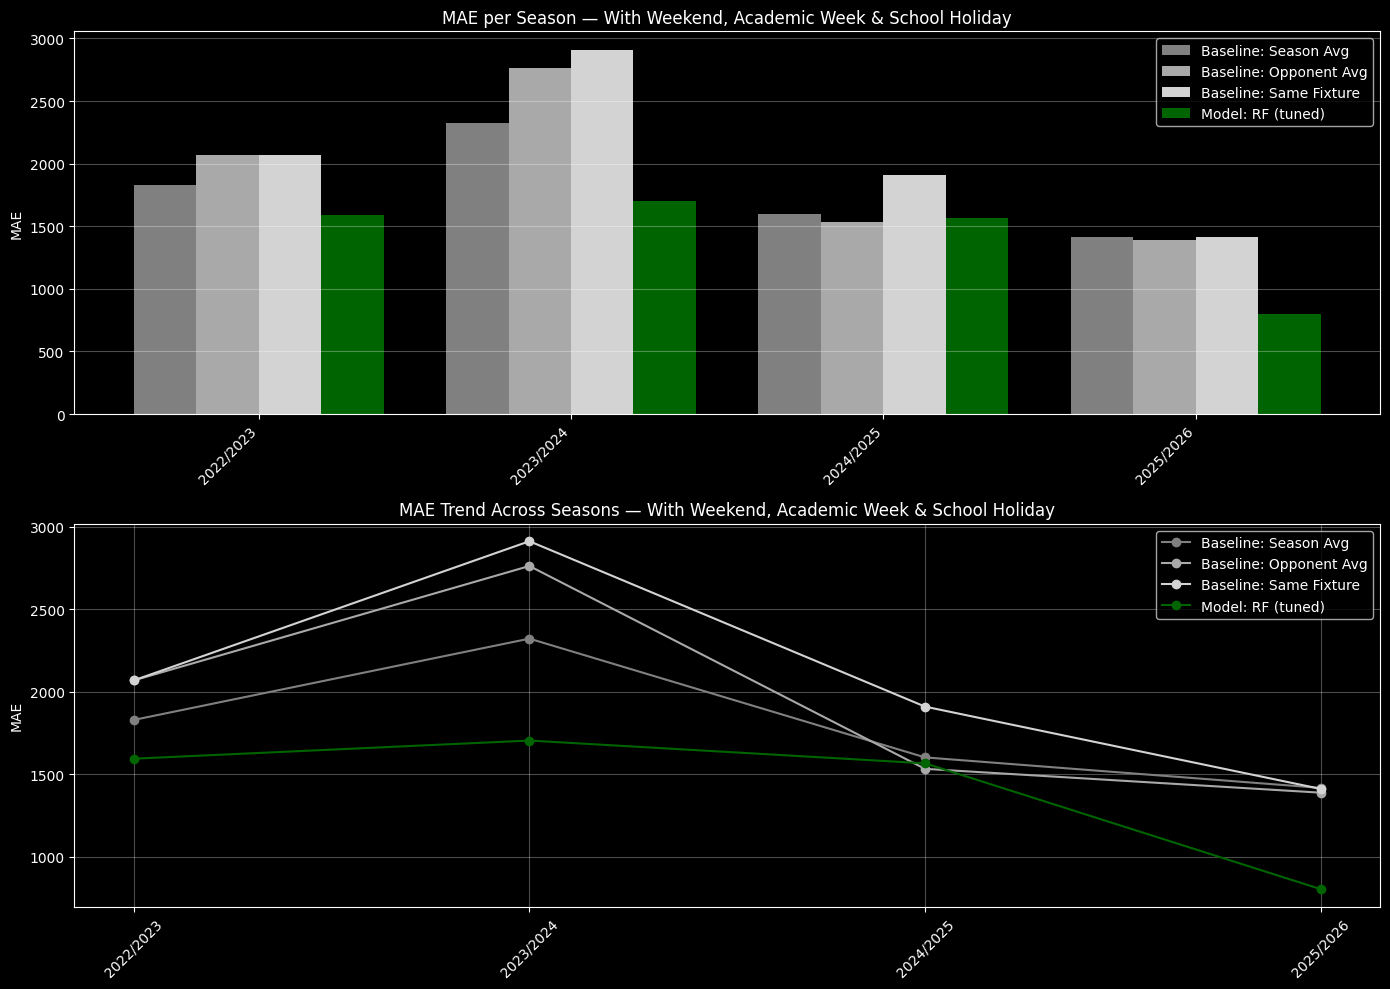

In [28]:
# Leave-One-Season-Out Cross Validation
for test_season in seasons:
    train = df[df["season"] != test_season].copy()
    test  = df[df["season"] == test_season].copy()

    # Need minimum data to train/test
    if len(train) < 10 or len(test) < 5:
        continue

    # Drop any remaining NAs strictly within the selected features
    train = train.dropna(subset=features)
    test  = test.dropna(subset=features)

    if len(test) == 0:
        continue

    # One-Hot Encoding
    X_train = pd.get_dummies(train[features], columns=categorical_features, drop_first=True)
    X_test  = pd.get_dummies(test[features],  columns=categorical_features, drop_first=True)

    # Align columns to ensure train and test have the exact same dummy variables
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_train = train["tickets_scanned"]
    y_test  = test["tickets_scanned"]

    # Baselines (Using our safely engineered features)
    # Season Avg: We only take the mean of the training set to prevent leakage
    season_avg_val = train["tickets_scanned"].mean()

    mae_season   = mean_absolute_error(y_test, [season_avg_val] * len(y_test))
    mae_opponent = mean_absolute_error(y_test, test["opponent_avg"])
    mae_fixture  = mean_absolute_error(y_test, test["same_fixture_baseline"])

    # Train Model
    rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
    rf.fit(X_train, y_train)
    mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

    season_results.append({
        "season":                 test_season,
        "n_matches":              len(y_test),
        "Baseline: Season Avg":   mae_season,
        "Baseline: Opponent Avg": mae_opponent,
        "Baseline: Same Fixture": mae_fixture,
        "Model: RF (tuned)":      mae_rf,
    })
    print(f"{test_season} — RF: {mae_rf:.0f} | Opponent Avg: {mae_opponent:.0f} | Season Avg: {mae_season:.0f} | Same Fixture: {mae_fixture:.0f} | n={len(y_test)}")

# -------------------------------------------------------------------
# VISUALIZATION
# -------------------------------------------------------------------
results_df = pd.DataFrame(season_results).set_index("season")

cols   = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", "Model: RF (tuned)"]
colors = ["grey", "darkgrey", "lightgrey", "darkgreen"]

x     = range(len(results_df))
width = 0.2

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top Plot: Bar Chart
for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0].bar([xi + i * width for xi in x], results_df[col], width=width, label=col, color=color)

axes[0].set_xticks([xi + width * 1.5 for xi in x])
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE per Season — With Weekend, Academic Week & School Holiday")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Bottom Plot: Line Chart
for col, color in zip(cols, colors):
    axes[1].plot(results_df.index, results_df[col], marker="o", label=col, color=color)

axes[1].set_ylabel("MAE")
axes[1].set_title("MAE Trend Across Seasons — With Weekend, Academic Week & School Holiday")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [29]:
results_df

,n_matches,Baseline: Season Avg,Baseline: Opponent Avg,Baseline: Same Fixture,Model: RF (tuned)
season,,,,,
2022/2023,13,1828.050296,2067.782090,2067.782090,1593.125989
2023/2024,19,2320.826087,2761.075188,2911.285714,1703.077557
2024/2025,20,1601.050000,1531.659357,1908.809357,1564.923277
2025/2026,13,1416.022189,1387.119231,1410.076923,802.484148


In [30]:
nan_values_last_result

,match_id,match_date,kickoff_time_local,match_date_utc,kickoff_time_utc,matchday,competition_id,competition_name,season,season_id,...,is_weekend,is_midweek,academic_year,academic_week,is_public_holiday,public_holiday_name,is_school_holiday_flanders,school_holiday_name,pct_free_tickets,campaign_motto
0,d256yo3eng04m0fu7b4sl7wno,2022-07-30,18:15:00,2022-07-30Z,16:15:00Z,2.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,True,False,2021/2022,48,False,NaN,True,Summer Holiday,13.9,NaN
17,3kewmr690bhoid47mku9wfgno,2023-08-05,20:45:00,2023-08-05Z,18:45:00Z,2.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2023/2024,f0atdrdim0sks9zagwg3an9jo,...,True,False,2022/2023,49,False,NaN,True,Summer Holiday,31.3,NaN
60,de191c5ia8dqmkvpzprawob2s,2025-09-20,16:00:00,2025-09-20Z,14:00:00Z,8.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2025/2026,16lkdpoccbh056r0v0bordo2c,...,True,False,2025/2026,3,False,NaN,False,NaN,50.1,NaN


In [31]:
nan_values_last_home_attendance_rolling

,match_id,match_date,kickoff_time_local,match_date_utc,kickoff_time_utc,matchday,competition_id,competition_name,season,season_id,...,opponent_avg,season_expanding_avg,month,month_cos,same_fixture_baseline,result_minus_1,result_minus_2,result_minus_3,points_last_3,is_18_hours
0,d4mn5ksbxuvnaww4pmommxhqs,2022-08-14,18,2022-08-14Z,16:30:00Z,4.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,NaN,NaN,8,-5.000000e-01,NaN,NaN,NaN,NaN,0.0,True
1,d65hmi7sq03yzr5he1k7ypus4,2022-08-27,18,2022-08-27Z,16:15:00Z,6.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,7440.0,7440.0,8,-5.000000e-01,7440.0,NaN,NaN,NaN,0.0,True
2,d80mkemezkz16bqh6lbn8tlhw,2022-09-10,20,2022-09-10Z,18:45:00Z,8.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,5964.5,5964.5,9,-1.836970e-16,5964.5,NaN,NaN,NaN,0.0,False


In [32]:
nan_values_last_result_numeric

,match_id,match_date,kickoff_time_local,match_date_utc,kickoff_time_utc,matchday,competition_id,competition_name,season,season_id,...,is_midweek,academic_year,academic_week,is_public_holiday,public_holiday_name,is_school_holiday_flanders,school_holiday_name,pct_free_tickets,campaign_motto,last_result_numeric
